In [1]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [2]:
case_name = "MPHYS AT10"
#User choice:
solveConduction = True
plot_at_z1 = []

########## Thermal hydraulics parameters ##########
## Geometric parameters
#User choice:
solveConduction = True
zPlotting = []

If = 8
I1 = 3
# Sensitivity to the meshing parameters
Iz1 = 75 # number of control volumes in the axial direction, added 70 for comparison with GeN-Foam
# Iz1 = 10, 20, 40, 50, 70, 80 and 160 are supported for the DONJON solution


########## Choice of Thermalhydraulics correlation ##########
voidFractionCorrel = 'EPRIvoidCorrel' # 'modBestion', 'HEM1', 'GEramp', 'EPRIvoidModel'
frfaccorel = "Churchill" # 'base', 'blasius', 'Churchill', 'Churchill_notOK' ?
P2Pcorel = "lockhartMartinelli" # 'base', 'HEM1', 'HEM2', 'MNmodel', "lockhartMartinelli"
numericalMethod = "FVM" # "FVM": Solves the system using matrix inversion with preconditioning.
                        # "GaussSiedel" : Applies the Gauss-Seidel iterative solver.
                        # "BiCG" : Uses the BiConjugate Gradient method for solving non-symmetric or indefinite matrices.
                        # "BiCGStab" : Applies the BiCGStab (BiConjugate Gradient Stabilized) method to ensure faster and more stable convergence.

########## Thermal hydraulics parameters ##########
## Geometric parameters
canalType = "square" # "square", "cylindrical"
pitch =1.295e-2 #1.295e-2 # m : ATRIUM10 pincell pitch   0.0126 #
fuelRadius = 0.4435e-2 # m : fuel rod radius
gapRadius = 0.4520e-2 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
cladRadius = 0.5140e-2 # m : clad external radius
height = 1.655 # m : height : 3.8 m : active core height in BWRX-300 SMR, 1.555 m : for GeNFoam comparison.


## Fluid parameters

# T_inlet, T_outlet = 270, 287 Celcius
#tInlet = 270 + 273.15 # K, for BWRX-300 SMR core, try lowering the inlet temperature to set boiling point back and reduce the void fraction increase in the first few cm
tInlet = 270 + 273.15 # K, for BWRX-300 SMR core
#Nominal operating pressure = 7.2 MPa (abs)
pOutlet =  7.2e6 # Pa 
# Nominal coolant flow rate = 1530 kg/s
massFlowRate = 8.407 * 10**(-2) #1530  / (200*91)  # kg/s

## Material parameters
kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
Hgap = 10000 
#Hgap = 9000
kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
# k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity


############ Nuclear Parameters ###########
# Number of fuel rods and assemblies for a small modular Boiling Water Reactor core
qFiss_init_1 = [0, 0, 0, 0, 0,2.564562941138757765e+08,
4.606563359818137884e+08,
6.385889898192162514e+08,
7.966173287146114111e+08,
9.346876843658176661e+08,
1.049026957254834294e+09,
1.130789081613284111e+09,
1.150140973202926397e+09,
1.108569337369034767e+09,
1.055785428336030245e+09,
1.004279242858528256e+09,
9.543893314359576702e+08,
9.089756320934396982e+08,
8.667470820122994184e+08,
8.280351174182662964e+08,
7.905057229690717459e+08,
7.554755728686988354e+08,
7.224685888143644333e+08,
6.911920184435430765e+08,
6.614450169170019627e+08,
6.331069528314148188e+08,
6.061197559277513027e+08,
5.807321145358361006e+08,
5.561661272914043665e+08,
5.326631014653288722e+08,
5.097330414569107294e+08,
4.877118743771567941e+08,
4.666589154829862714e+08,
4.464917281279732585e+08,
4.271445942088661790e+08,
4.085647347076887488e+08,
3.907097752317554355e+08,
3.735427215578536391e+08,
3.570304700811994076e+08,
3.411426295138564706e+08,
3.258510095463058352e+08,
3.111291984374625087e+08,
2.969528075678178072e+08,
2.832995603678619266e+08,
2.701503149949405193e+08,
2.574903982595574856e+08,
2.453126514238079488e+08,
2.337728548494936228e+08,
2.224196967991268337e+08,
2.114198958303166032e+08,
2.007686275762138665e+08,
1.904553762510111630e+08,
1.804682587944314182e+08,
1.707903676903969944e+08,
1.614050622080946565e+08,
1.522962574193436801e+08,
1.434483241541218162e+08,
1.348461223487246335e+08,
1.264747120283900201e+08,
1.183196645567856878e+08,
1.103668958952060193e+08,
1.026025887902103215e+08,
9.501365964783260226e+07,
8.758616338002669811e+07,
8.030739989664377272e+07,
7.316446901858410239e+07,
6.614427047780513018e+07,
5.923332050244478136e+07,
5.241720713024570048e+07,
4.567945637118443847e+07,
3.899987591562700272e+07,
3.235112583208712190e+07,
2.569273257287562639e+07,
1.896002294369014725e+07,
1.204371086243382096e+07,
]

qFiss_init_2 = [0,0,0,0,0,6.636480184627691656e+07,
1.203607274475849271e+08,
1.690703808642655015e+08,
2.146628930296683908e+08,
2.577359073983282149e+08,
2.982980722592046261e+08,
3.361638606936126947e+08,
3.710920765912090540e+08,
4.028398786658587456e+08,
4.311784763219730854e+08,
4.558899504634524584e+08,
4.767562930657761097e+08,
4.935055610169775486e+08,
5.056673674332319498e+08,
5.122225481436123848e+08,
5.106402892097806931e+08,
4.903793712988448739e+08,
4.675438422021413445e+08,
4.447928840339780450e+08,
4.225981731402893662e+08,
4.012143115909135342e+08,
3.809644208042048812e+08,
3.618054594243107438e+08,
3.436913625290604830e+08,
3.265364920488602519e+08,
3.100894251049303412e+08,
2.945607219665191770e+08,
2.798697912519288659e+08,
2.660304835627623498e+08,
2.527302599627852142e+08,
2.400498674584244490e+08,
2.279685857275490165e+08,
2.164604921353839338e+08,
2.054992638692601919e+08,
1.950610236480921209e+08,
1.851266296292180121e+08,
1.756848545994669199e+08,
1.667889444510197043e+08,
1.582308511425252259e+08,
1.500270375479567647e+08,
1.421621301665021181e+08,
1.346508133037085235e+08,
1.274698432934909016e+08,
1.205990111521343738e+08,
1.140199865088252872e+08,
1.077157951511709690e+08,
1.016705077757261097e+08,
9.586909547931301594e+07,
9.029725190217395127e+07,
8.494127095139469206e+07,
7.978811349721983075e+07,
7.482520728410516679e+07,
7.004060255545543134e+07,
6.542274973256790638e+07,
6.096055499490257353e+07,
5.664330802573297173e+07,
5.246067089609701931e+07,
4.840278922532279789e+07,
4.445964744997500628e+07,
4.062192753892236948e+07,
3.688036704129523039e+07,
3.322579799267385527e+07,
2.964893015205778554e+07,
2.614005642647267878e+07,
2.268835811767945439e+07,
1.928051819460653886e+07,
1.589799786045122705e+07,
1.251142433559936099e+07,
9.069241367872400209e+06,
5.474506904262065887e+06]

qFiss_init_10 = [0,0,0,0,0,
    1.188720795721113682e+07,
    2.166433901076181233e+07,
    3.063888689465070516e+07,
    3.924987038164068013e+07,
    4.764847056674949080e+07,
    5.587817344793375582e+07,
    6.394260841638284922e+07,
    7.183083171826541424e+07,
    7.952711969711169600e+07,
    8.701417577500236034e+07,
    9.427484232467614114e+07,
    1.012924397091356218e+08,
    1.080509663705947548e+08,
    1.145353822898221165e+08,
    1.207316145441654772e+08,
    1.266257569517628551e+08,
    1.322057152473345101e+08,
    1.374595730224424899e+08,
    1.423767589110184312e+08,
    1.469472462335743308e+08,
    1.511621421479930282e+08,
    1.550131207308416367e+08,
    1.584929231997406483e+08,
    1.615952022886283696e+08,
    1.643138997488127649e+08,
    1.666443468381815553e+08,
    1.685825195456771851e+08,
    1.701251386357661784e+08,
    1.712697363447633088e+08,
    1.720147230771400332e+08,
    1.723589649955237806e+08,
    1.723025065641276538e+08,
    1.718459258176884651e+08,
    1.709906344948924780e+08,
    1.697383111196902394e+08,
    1.680915679644514322e+08,
    1.660527727483924031e+08,
    1.636230037286199331e+08,
    1.607987593485476971e+08,
    1.575632432526278794e+08,
    1.538627649065727592e+08,
    1.495448231841126978e+08,
    1.440627528481547236e+08,
    1.370819162497994900e+08,
    1.303943433523885757e+08,
    1.239191426408067793e+08,
    1.176924524022089690e+08,
    1.116219315872550458e+08,
    1.057039230146234185e+08,
    9.994396247853246331e+07,
    9.432403085764075816e+07,
    8.883233402008943260e+07,
    8.347345177957002819e+07,
    7.824712290884284675e+07,
    7.313907995433744788e+07,
    6.814736093276071548e+07,
    6.326705254884253442e+07,
    5.849279130718050897e+07,
    5.381833554421313852e+07,
    4.923203007874011248e+07,
    4.473135156680899858e+07,
    4.031034180420227349e+07,
    3.596065541439440846e+07,
    3.167363855039939657e+07,
    2.743933678707150742e+07,
    2.324465402488551661e+07,
    1.906880741391054541e+07,
    1.487255867780785449e+07,
    1.057252352665627003e+07,
    5.979247601419438608e+06
]

qFiss_init_15 = [0,0,0,0,0,
    3.384843589158619940e+07,
    6.155325736403551698e+07,
    8.677582537413688004e+07,
    1.106952307422523201e+08,
    1.336761800396902561e+08,
    1.557828740285157263e+08,
    1.769711819797185957e+08,
    1.971614684921328723e+08,
    2.162665170166871250e+08,
    2.341993333253628016e+08,
    2.508739680990902185e+08,
    2.662126089693376124e+08,
    2.801461363207431436e+08,
    2.926118556163768768e+08,
    3.035545200745795369e+08,
    3.129249522784388661e+08,
    3.206815781910552382e+08,
    3.267839131486867666e+08,
    3.311852474981076121e+08,
    3.338110147581589818e+08,
    3.344966528854504228e+08,
    3.328308012357123494e+08,
    3.277338243116174340e+08,
    3.147080338193971515e+08,
    3.005652356608514190e+08,
    2.866444250736742020e+08,
    2.731668559697605968e+08,
    2.601741690823237598e+08,
    2.476352172318497002e+08,
    2.354947314045753777e+08,
    2.238915288659580350e+08,
    2.128016434064933062e+08,
    2.022055552377312481e+08,
    1.920845226949083209e+08,
    1.824204488443154991e+08,
    1.731930357738159001e+08,
    1.643822968207522035e+08,
    1.559702239798355401e+08,
    1.479419106244633794e+08,
    1.402264696869056523e+08,
    1.328587166440531760e+08,
    1.258198209027213007e+08,
    1.190888953999861181e+08,
    1.126479543626624197e+08,
    1.064803237117808312e+08,
    1.005704965538981706e+08,
    9.490391086004485190e+07,
    8.946592678888574243e+07,
    8.424512815435147285e+07,
    7.922790334997530282e+07,
    7.440190799929229915e+07,
    6.975538131860150397e+07,
    6.527699605025589466e+07,
    6.095582511450111121e+07,
    5.678141942185055465e+07,
    5.274364113228914887e+07,
    4.883264698119762540e+07,
    4.503911060040482879e+07,
    4.135346106858133525e+07,
    3.776690003005710989e+07,
    3.427061801310796291e+07,
    3.085592226456476375e+07,
    2.751406167198047042e+07,
    2.423592385119737685e+07,
    2.101138624677344784e+07,
    1.782790300378951803e+07,
    1.466752030771346018e+07,
    1.150049993870032392e+07,
    8.271445743135184981e+06,
    4.869404925777672790e+06
]

qFiss_init_20 = [0,0,0,0,0,
    6.802816905824910104e+07,
    1.233784467239843011e+08,
    1.732716040339279175e+08,
    2.199232314634694457e+08,
    2.639339738013583720e+08,
    3.053031196202252507e+08,
    3.438327809508410692e+08,
    3.792680667060011029e+08,
    4.113525073190245628e+08,
    4.398416163279846311e+08,
    4.644943977114857435e+08,
    4.850446887049385905e+08,
    5.010942233740916848e+08,
    5.118605650052025914e+08,
    5.154927129756341577e+08,
    5.051623429293541908e+08,
    4.837129411335693002e+08,
    4.613169852227544188e+08,
    4.392459292987164855e+08,
    4.174471277361175418e+08,
    3.967176015097780824e+08,
    3.770593070449638367e+08,
    3.584416529647873044e+08,
    3.408320025386759043e+08,
    3.239463183893850446e+08,
    3.079197050207902789e+08,
    2.927397124539279342e+08,
    2.783303513528962135e+08,
    2.646395541270988882e+08,
    2.516164537196213603e+08,
    2.392188758267156482e+08,
    2.274098039930696785e+08,
    2.161557122038975954e+08,
    2.054258534575767815e+08,
    1.951922819977525771e+08,
    1.854301312146498859e+08,
    1.761161574421859086e+08,
    1.672291401358566284e+08,
    1.587170450532170832e+08,
    1.505597076747673750e+08,
    1.427696002115770578e+08,
    1.353211112783465683e+08,
    1.281927424292564094e+08,
    1.213654074019091427e+08,
    1.148216984578608423e+08,
    1.085452972318250090e+08,
    1.025208079908834249e+08,
    9.673363535791164637e+07,
    9.116993428933680058e+07,
    8.581643221829791367e+07,
    8.066036791635575891e+07,
    7.568961377007202804e+07,
    7.089242566982544959e+07,
    6.625753193822945654e+07,
    6.177411109803391993e+07,
    5.743169738567060977e+07,
    5.322018075125671923e+07,
    4.912987911293637007e+07,
    4.515096032214292884e+07,
    4.127432033175860345e+07,
    3.749084675762444735e+07,
    3.379151058597884327e+07,
    3.016719387463735789e+07,
    2.660829235411264375e+07,
    2.310405819100124389e+07,
    1.964122576597507298e+07,
    1.620118819640897214e+07,
    1.275430869643839635e+07,
    9.248402956910237670e+06,
    5.585128302182634361e+06
]

qFiss_init_25 = [0,0,0,0,0,
    1.095377828763947785e+08,
    1.981488629845905304e+08,
    2.772813516966670156e+08,
    3.502723324815832973e+08,
    4.178790530777853131e+08,
    4.799435321450482607e+08,
    5.360085886700900793e+08,
    5.854688868899440765e+08,
    6.275922791130419970e+08,
    6.612840564746685028e+08,
    6.843870822622801065e+08,
    6.918049575865197182e+08,
    6.623207395445638895e+08,
    6.316922350430874825e+08,
    6.006317162715209723e+08,
    5.706136609172259569e+08,
    5.423763082686240673e+08,
    5.158983599688429236e+08,
    4.904300160347076058e+08,
    4.665907073839418292e+08,
    4.441558452888599038e+08,
    4.229706942966099977e+08,
    4.029105322964860797e+08,
    3.838846078346750736e+08,
    3.658252908468720317e+08,
    3.486896956019623876e+08,
    3.321254209989199638e+08,
    3.164062554144452810e+08,
    3.014490730068459511e+08,
    2.871925131655081511e+08,
    2.735884878466750383e+08,
    2.605968458681883812e+08,
    2.481822381826280951e+08,
    2.363127839510014355e+08,
    2.249592924190574586e+08,
    2.140949072035967410e+08,
    2.036942170082706213e+08,
    1.937338558904141188e+08,
    1.841921808955199122e+08,
    1.750474379085598886e+08,
    1.662778394663442373e+08,
    1.578635100667393804e+08,
    1.497857302770878077e+08,
    1.420266254847303629e+08,
    1.345692659414872229e+08,
    1.273973666302298754e+08,
    1.204954317735659331e+08,
    1.138485769770024419e+08,
    1.074424291844656616e+08,
    1.012632600709360838e+08,
    9.529776372139476240e+07,
    8.953316223332352936e+07,
    8.395717792657415569e+07,
    7.855785548652185500e+07,
    7.332378428512658179e+07,
    6.824385938579277694e+07,
    6.330745384218949825e+07,
    5.850630842719974369e+07,
    5.382404363724757731e+07,
    4.925326729732296616e+07,
    4.478433345273965597e+07,
    4.040746831420890242e+07,
    3.611264242322909832e+07,
    3.188921493840352446e+07,
    2.772517496484666690e+07,
    2.360563255003733560e+07,
    1.950995491075538471e+07,
    1.540610141475127637e+07,
    1.123953462347711995e+07,
    6.911477987861100584e+06
]

qFiss_init_30 = [0,0,0,0,0,
    1.560858309273678958e+08,
    2.816664788413279653e+08,
    3.928042618715783954e+08,
    4.939637202428932190e+08,
    5.859651074801237583e+08,
    6.682178499382191896e+08,
    7.394505824437915087e+08,
    7.974962972295464277e+08,
    8.379147092975866795e+08,
    8.469151548051308393e+08,
    8.155545470762952566e+08,
    7.787147036049261093e+08,
    7.405873544517239332e+08,
    7.045438649920160770e+08,
    6.703017540959222317e+08,
    6.379120222129890919e+08,
    6.077441224690085649e+08,
    5.794712873803577423e+08,
    5.528631034077583551e+08,
    5.277816870341722965e+08,
    5.035810177439461350e+08,
    4.805831942785906792e+08,
    4.587855932496786714e+08,
    4.380593573749216795e+08,
    4.183039975383894444e+08,
    3.994453474368174076e+08,
    3.814231580648586154e+08,
    3.641868513829616308e+08,
    3.476918075558055639e+08,
    3.318984979001759887e+08,
    3.167709953339116573e+08,
    3.022761517880228162e+08,
    2.883838427598335147e+08,
    2.750663225819358230e+08,
    2.623063836048327982e+08,
    2.500545816263450086e+08,
    2.382960211359287798e+08,
    2.270088257419739068e+08,
    2.161730754781328440e+08,
    2.057710958206996024e+08,
    1.957808992175365686e+08,
    1.861140018895703852e+08,
    1.768353438163680434e+08,
    1.679144003173572123e+08,
    1.593272941114538610e+08,
    1.510536050099445879e+08,
    1.430748247851692736e+08,
    1.353740014568428695e+08,
    1.279350500967838168e+08,
    1.207428195252337456e+08,
    1.137826921329613179e+08,
    1.070406839257360995e+08,
    1.005033889440663457e+08,
    9.415774582608835399e+07,
    8.799124901257680357e+07,
    8.199169307772386074e+07,
    7.614730612177594006e+07,
    7.044686648958545923e+07,
    6.487864118758313358e+07,
    5.943195880522803217e+07,
    5.409594784302922338e+07,
    4.885979793978889287e+07,
    4.371237636878009140e+07,
    3.864184175492016226e+07,
    3.363475201154525578e+07,
    2.867446362882904708e+07,
    2.373800806298885867e+07,
    1.879026692469840124e+07,
    1.377284203137471341e+07,
    8.582704249054985121e+06
]

qFiss_init_35 = [0,0,0,0,0,
    2.063101132135721445e+08,
    3.714426324274973273e+08,
    5.163186801515457034e+08,
    6.464608002693649530e+08,
    7.623811315585261583e+08,
    8.623816747450339794e+08,
    9.424989790253539085e+08,
    9.941199710945982933e+08,
    9.848229493024215698e+08,
    9.471479790277587175e+08,
    9.027705625772427320e+08,
    8.598363654740436077e+08,
    8.184767349962419271e+08,
    7.798197281664994955e+08,
    7.440290622082021236e+08,
    7.106763689165301323e+08,
    6.792467527328594923e+08,
    6.488453269548641443e+08,
    6.202527497278621197e+08,
    5.931739120861704350e+08,
    5.674200634558393955e+08,
    5.428599010229978561e+08,
    5.193964928085575104e+08,
    4.969542496545164585e+08,
    4.754727002344753146e+08,
    4.549039121294171810e+08,
    4.352217403835175633e+08,
    4.163459715608664155e+08,
    3.982595758688143492e+08,
    3.809460126210217476e+08,
    3.641520359060699940e+08,
    3.480079925573081374e+08,
    3.325465415374122858e+08,
    3.177134365094632506e+08,
    3.034673035255087614e+08,
    2.897742830891805291e+08,
    2.766047842683355212e+08,
    2.639321730008304715e+08,
    2.517317271855736375e+08,
    2.399804588256941140e+08,
    2.286564915295805037e+08,
    2.177389938145716190e+08,
    2.072081124106402099e+08,
    1.970449722603879273e+08,
    1.872316765190555155e+08,
    1.777515288755665123e+08,
    1.685851429341011345e+08,
    1.597153110451638997e+08,
    1.511256259150463343e+08,
    1.428004806058315337e+08,
    1.347246794735504985e+08,
    1.268836049089718610e+08,
    1.192631284091820270e+08,
    1.118495661133684367e+08,
    1.046295787583578229e+08,
    9.759027172307798266e+07,
    9.071904496185310185e+07,
    8.400384311558708549e+07,
    7.743206613860410452e+07,
    7.099218112628319860e+07,
    6.467242173689495772e+07,
    5.846093270029307157e+07,
    5.234555861290690303e+07,
    4.631318253261252493e+07,
    4.034893395998087525e+07,
    3.443424630807764083e+07,
    2.854373051265617833e+07,
    2.263900562293817475e+07,
    1.665740211311094649e+07,
    1.049068575755944848e+07
]

qFiss_init_40 = [0,0,0,0,0,
    2.599107630987913609e+08,
    4.668621613895918131e+08,
    6.468608003078289032e+08,
    8.061902953977071047e+08,
    9.444285479080996513e+08,
    1.056886540047070742e+09,
    1.132358757175517797e+09,
    1.128369072487735271e+09,
    1.086567378828253031e+09,
    1.036697654157290101e+09,
    9.882544302904622555e+08,
    9.416614511546884775e+08,
    8.989984857360846996e+08,
    8.596184019137345552e+08,
    8.221508127172615528e+08,
    7.864077234642931223e+08,
    7.528753058334197998e+08,
    7.211610297735564709e+08,
    6.910147841001330614e+08,
    6.622582228644748926e+08,
    6.347712482337830067e+08,
    6.084708010626757145e+08,
    5.833259787247902155e+08,
    5.592462965515768528e+08,
    5.360372236217091084e+08,
    5.134163677337309718e+08,
    4.918072504935106635e+08,
    4.711029354745730758e+08,
    4.512327690462985635e+08,
    4.321413488022921681e+08,
    4.137802087530049086e+08,
    3.961101759289137125e+08,
    3.790970573520730734e+08,
    3.627096391466491222e+08,
    3.469193752894449830e+08,
    3.316992315404171348e+08,
    3.170239522279558182e+08,
    3.028695489104476571e+08,
    2.892136338578563929e+08,
    2.760351088022617102e+08,
    2.633154099357410073e+08,
    2.510669427730487287e+08,
    2.391896628403594792e+08,
    2.276982210950590074e+08,
    2.165762769397592247e+08,
    2.058071340633834898e+08,
    1.953740961548524201e+08,
    1.852615118120415211e+08,
    1.754531515980845988e+08,
    1.659307296063766181e+08,
    1.566779608197892308e+08,
    1.476791493719842434e+08,
    1.389191329671519995e+08,
    1.303832050676358789e+08,
    1.220571482421039939e+08,
    1.139270007284298241e+08,
    1.059791787102782428e+08,
    9.820074310236771405e+07,
    9.057796557967866957e+07,
    8.309831835087832808e+07,
    7.574901239739339054e+07,
    6.851710307591843605e+07,
    6.138923444919677824e+07,
    5.435100567102374136e+07,
    4.738600388966542482e+07,
    4.047383670654018223e+07,
    3.358674178016114980e+07,
    2.668332848849573359e+07,
    1.969710755214031786e+07,
    1.251528160586800613e+07
]

qFiss_init_45 = [0,0,0,0,0,
    3.167533652744132876e+08,
    5.676127268803248405e+08,
    7.837272429931113720e+08,
    9.716945354121613503e+08,
    1.128676764825015306e+09,
    1.243377442817703962e+09,
    1.274485493830390692e+09,
    1.234666548249519348e+09,
    1.180341865391164541e+09,
    1.126142571606672287e+09,
    1.074394056181457043e+09,
    1.027268929373347044e+09,
    9.835777735490695238e+08,
    9.413004906931233406e+08,
    9.020156492098538876e+08,
    8.650500609509351254e+08,
    8.300031033789592981e+08,
    7.966236426325161457e+08,
    7.647585439703310728e+08,
    7.343590746175981760e+08,
    7.053355057973513603e+08,
    6.766849917039527893e+08,
    6.492562651891330481e+08,
    6.230094863202043772e+08,
    5.978169538843562603e+08,
    5.735932076688340902e+08,
    5.502754197440775633e+08,
    5.278144571573768258e+08,
    5.061695462276294827e+08,
    4.853060493347859979e+08,
    4.651940865293229222e+08,
    4.458125373112173080e+08,
    4.271844786057628989e+08,
    4.091474381874652505e+08,
    3.917269385132047534e+08,
    3.749002139071537256e+08,
    3.586439428908637762e+08,
    3.429348706821961999e+08,
    3.277503205337453485e+08,
    3.130679714118002653e+08,
    2.988662359421180487e+08,
    2.851239713925632834e+08,
    2.718206575299502611e+08,
    2.589364188521414399e+08,
    2.464517800349025726e+08,
    2.343479549492593408e+08,
    2.226066021083401442e+08,
    2.112098468994913995e+08,
    2.001403927447925806e+08,
    1.893815877973779440e+08,
    1.789191479295955300e+08,
    1.687335867011544704e+08,
    1.588080632922955453e+08,
    1.491264705427279174e+08,
    1.396732348626973629e+08,
    1.304332495366544574e+08,
    1.213917413306308240e+08,
    1.125346262059222013e+08,
    1.038469530717178583e+08,
    9.531506029931508005e+07,
    8.692492498829631507e+07,
    7.866245754193384945e+07,
    7.051296253862687945e+07,
    6.246067741572140902e+07,
    5.448757749384965748e+07,
    4.657146957390110940e+07,
    3.868243480017529428e+07,
    3.077643693010955304e+07,
    2.278391170623670518e+07,
    1.458879642286459729e+07
]

qFiss_init_50 = [0,0,0,0,0,
    3.777932777691656947e+08,
    6.754195402705723047e+08,
    9.294385953772957325e+08,
    1.146391484180748940e+09,
    1.320073403949997663e+09,
    1.430077327378108263e+09,
    1.392749978301834822e+09,
    1.333472338097484827e+09,
    1.272743919630017757e+09,
    1.214731108360099077e+09,
    1.162542664035310507e+09,
    1.113419760245410442e+09,
    1.066909039899225831e+09,
    1.023755634237822652e+09,
    9.831906681316790581e+08,
    9.447561602117224932e+08,
    9.082215190818402767e+08,
    8.734021293396641016e+08,
    8.394483688492437601e+08,
    8.063123941199851036e+08,
    7.746982514623677731e+08,
    7.443872658887118101e+08,
    7.152515583293579817e+08,
    6.871951305536434650e+08,
    6.601461283972589970e+08,
    6.340540849811835289e+08,
    6.088817837611567974e+08,
    5.846739557330226898e+08,
    5.612117925164790154e+08,
    5.385369126126371622e+08,
    5.166238380288213491e+08,
    4.954471352365823984e+08,
    4.749816819569345117e+08,
    4.552039566224757433e+08,
    4.360910157005439997e+08,
    4.176116453152989745e+08,
    3.997401006888158321e+08,
    3.824515263273745775e+08,
    3.657222672709359527e+08,
    3.495292243621043563e+08,
    3.338501877276884317e+08,
    3.186633476723938584e+08,
    3.039474503035604358e+08,
    2.896819753879964948e+08,
    2.758467139419936538e+08,
    2.624223462660504580e+08,
    2.493900639990836382e+08,
    2.367321703852824271e+08,
    2.244321692025168240e+08,
    2.124756985107663274e+08,
    2.008882807669094503e+08,
    1.895445491291887760e+08,
    1.784771847923894525e+08,
    1.676695803738509417e+08,
    1.571065513456622362e+08,
    1.467726019304310977e+08,
    1.366522363507670164e+08,
    1.267305368640172184e+08,
    1.169914185420009047e+08,
    1.074202193112772405e+08,
    9.800179910813724995e+07,
    8.872086224414134026e+07,
    7.956147941584470868e+07,
    7.050656525032831728e+07,
    6.153661107519596815e+07,
    5.262780074765063077e+07,
    4.374830345093647391e+07,
    3.485195977643518895e+07,
    2.586684886351838335e+07,
    1.667484319971454516e+07
]

case0 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_25, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)
    

caseMerge = [case0]#, case1, case2, case3, case4, case5, case6, case7, case8]

$$$---------- THM: prototype, case treated : Initialization of BWR Pincell equivalent canal.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.655 m with 75 axial elements.
self.I_z: 75
self.qFlow: 0.08407
self.pOutlet: 7200000.0
self.Lf: 1.655
self.r_f: 0.004435
self.clad_r: 0.00514
self.r_w: 0.01295
self.Dz: 0.02206666666666667
self.dt: 0
Courant number: 0.0
Numerical Method FVM
Velocity at the inlet:  1.2879381112870212
cote: 0.01295
cladRadius: 0.00514
Dh: 0.010490958633360763
Hydraulic diameter: [0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.01049095863336

c:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\THM_waterProp.py:573: RuntimeWarning: divide by zero encountered in scalar divide
  return self.U[i] - (self.voidFractionTEMP[i] / ( 1 - self.voidFractionTEMP[i])) * (self.rhogTEMP[i] / self.rhoTEMP[i]) * self.VgjPrimeTEMP[i]
c:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\THM_waterProp.py:589: RuntimeWarning: invalid value encountered in sqrt
  return 1 + 1/np.sqrt(X) + 20/X


Inside Ul
Void fraction: 0.27255469002772853
rho: 545.7157190275487, rho_g: 37.73860715163978
VgjPrime: 0.5637166585616091
U: 1.3213703214812529
(1 - voidFraction): 0.7274453099722715
Inside Ul
Void fraction: 0.23110648811395015
rho: 574.6579907579786, rho_g: 37.73914826270123
VgjPrime: 0.5385245291123106
U: 1.3196575424319985
(1 - voidFraction): 0.7688935118860498
Inside Ug
Void fraction: 0.23110648811395015
rho_l: 736.0398026384256, rho_g: 37.73914826270123
Inside Ul
Void fraction: 0.27255469002772853
rho: 545.7157190275487, rho_g: 37.73860715163978
VgjPrime: 0.5637166585616091
U: 1.3213703214812529
(1 - voidFraction): 0.7274453099722715
Inside Ug
Void fraction: 0.27255469002772853
rho_l: 736.0414278754024, rho_g: 37.73860715163978
Inside Ul
Void fraction: 0.27255469002772853
rho: 545.7157190275487, rho_g: 37.73860715163978
VgjPrime: 0.5637166585616091
U: 1.3213703214812529
(1 - voidFraction): 0.7274453099722715
Inside Ug
Void fraction: 0.27255469002772853
rho_l: 736.0414278754024, r

In [3]:

class GFPlotter():
    def __init__(self, caseList, directory_path, case_name):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def plotCase(self):
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        labelTitle = 'DFM'
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)

        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GenFoam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)

        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"DFM {self.caseList[i].convection_sol.frfaccorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    #end = start + 74
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        #end = start
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid'])#+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour'])#+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        #self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        print(f"rho_liquid GeN-Foam: {self.rho_liquid}")
        print(f"rho_vapour GeN-Foam: {self.rho_vapour}")
        self.rho_mixture = self.rho_liquid + self.rho_vapour

        self.T_mixture = (1-self.alpha_vapour) * self.T_liquid + self.alpha_vapour * self.T_vapour

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'DFM'
        labelTitle = 'DFM'
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        
        fig0, ax0 = plt.subplots()
        for i in range(len(self.caseList)):
            ax0.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax0.set_xlabel("Axial position in m")
        ax0.set_ylabel("xTh")
        ax0.set_title(f"{title}")
        ax0.grid()
        ax0.legend(loc="best")
        fig0.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.step(self.zList, self.T_liquid, label="GenFoam T.liquid")
        ax1.step(self.zList, self.T_vapour, label="GenFoam T.vapour")
        ax1.step(self.zList, self.T_mixture, label="GenFoam T.mixture")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GenFoam")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GeN-Foam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GenFoam")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GenFoam")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GenFoam")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"DFM {self.caseList[i].convection_sol.frfaccorel} {self.caseList[i].convection_sol.P2Pcorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GenFoam")
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GenFoam")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GenFoam")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GenFoam")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GenFoam")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def computeErrors(self):
        self.error_T_abs = []
        self.error_T_rel = []
        self.error_p_abs = []
        self.error_p_rel = []
        self.error_rho_abs = []
        self.error_rho_rel = []
        self.error_U_abs = []
        self.error_U_rel = []
        self.error_Re_abs = []
        self.error_Re_rel = []
        self.error_eps_abs = []
        self.error_eps_rel = []

        for i in range(len(self.caseList)):
            self.error_T_abs.append((self.T_mixture - self.caseList[i].convection_sol.T_water))
            self.error_T_rel.append(100*self.error_T_abs[-1]/(self.T_mixture))
            self.error_p_abs.append((self.p - self.caseList[i].convection_sol.P[-1]))
            self.error_p_rel.append(100*self.error_p_abs[-1]/(self.p))
            self.error_rho_abs.append(self.rho_mixture - self.caseList[i].convection_sol.rho[-1])
            self.error_rho_rel.append(100*self.error_rho_abs[-1]/(self.rho_mixture))
            self.error_U_abs.append((self.U_mixture - self.caseList[i].convection_sol.U[-1]))
            self.error_U_rel.append(100*self.error_U_abs[-1]/(self.U_mixture))
            self.error_Re_abs.append((self.Re_liquid_structure - self.caseList[i].convection_sol.Rel))
            self.error_Re_rel.append(100*self.error_Re_abs[-1]/(self.Re_liquid_structure))
            self.error_eps_abs.append((self.alpha_vapour - self.caseList[i].convection_sol.voidFraction[-1]))
            self.error_eps_rel.append(self.error_eps_abs[-1]/(self.alpha_vapour))

            

    def plotErrorsPressure(self):
        fig, ax = plt.subplots()
        for i in range(len(self.caseList)):
            print(self.error_p_abs)
            ax.step(self.caseList[i].convection_sol.z_mesh, self.error_p_abs[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax.set_xlabel("Axial position in m")
        ax.set_ylabel("Absolute error in Pa")
        ax.set_title("Absolute error in pressure")
        ax.grid()
        ax.legend(loc="best")
        fig.savefig(rf'result\{self.case_name}\error_p_abs.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.error_p_rel[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Relative error in %")
        ax1.set_title("Relative error in pressure")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\error_p_rel.png', bbox_inches='tight')

        plt.show()

        for i in range(len(self.caseList)):
            print(f"Mean relative error in pressure: {np.mean(self.error_p_rel[i])}, max relative error in pressure {np.max(self.error_p_rel[i])} for {self.caseList[i].convection_sol.frfaccorel}, {self.caseList[i].convection_sol.P2Pcorel}")


Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW\alpha.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW\alpha.passiveStructure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW\alpha.powerModel
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW\alpha.structure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW\alpha.vapour
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW\alphaPhi.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW\alphaPhi

C:\Users\cleme\AppData\Local\Temp\ipykernel_24660\1194667784.py:264: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)


rho_mix GeN-Foam: [762.67183469 762.67183469 762.67183469 762.67183469 762.67183469
 762.44852698 762.02128123 761.40025631 760.55804126 787.44802785
 786.32118362 785.05336718 783.66089313 782.16217815 780.60868409
 779.06550044 777.59084022 776.68771263 775.95865117 775.3206773
 774.76096786 774.25998546 773.81077524 773.41100278 773.05161936
 772.73808543 772.44712965 772.17745561 771.91656644 771.67281852
 771.43803255 771.22241118 771.0260966  770.83451901 770.65738308
 770.5000551  770.34959929 770.21227256 770.09009519 769.97987637
 769.87808674 769.79023247 769.70614402 769.64088802 769.58111547
 769.52846437 769.4882167  769.44687653 769.42111396 769.39428647
 769.37650661 769.35461741 769.32796218 769.29533129 769.27333607
 769.24848957 769.22582771 769.20534865 769.19223692 769.18475809
 769.17074949 769.1694727  769.16665906 769.169496   769.17629823
 769.18690471 769.20130041 769.21964177 769.23471593 769.25894414
 769.29223824 769.32237522 769.3614658  769.41156457 769.41

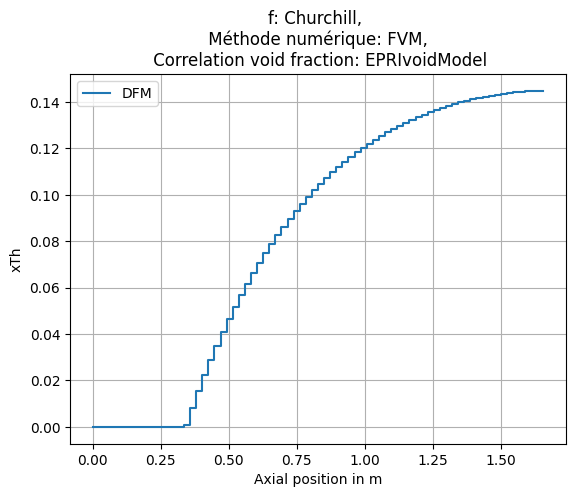

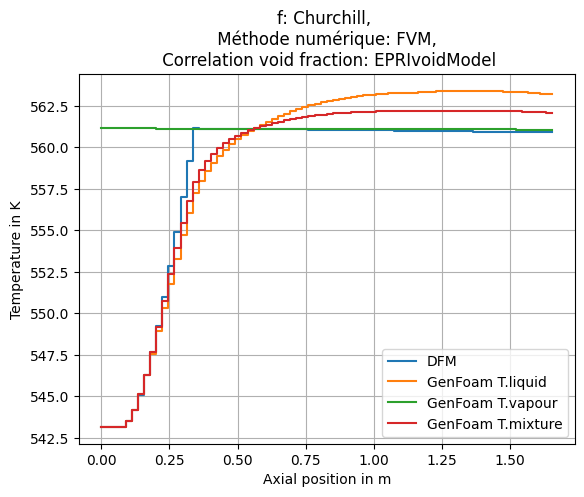

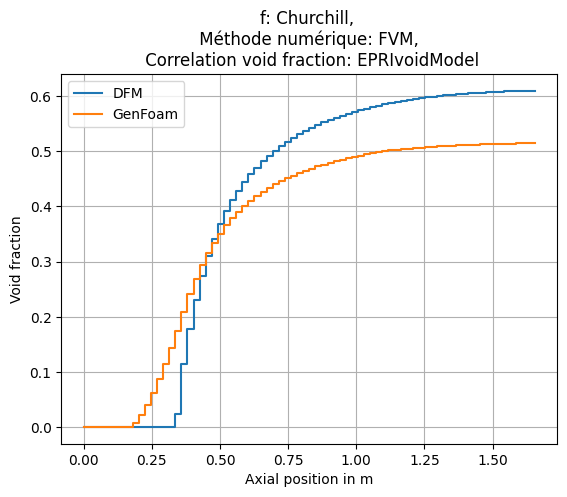

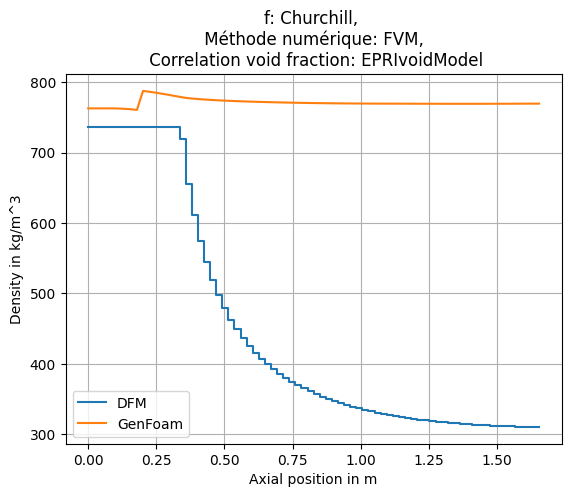

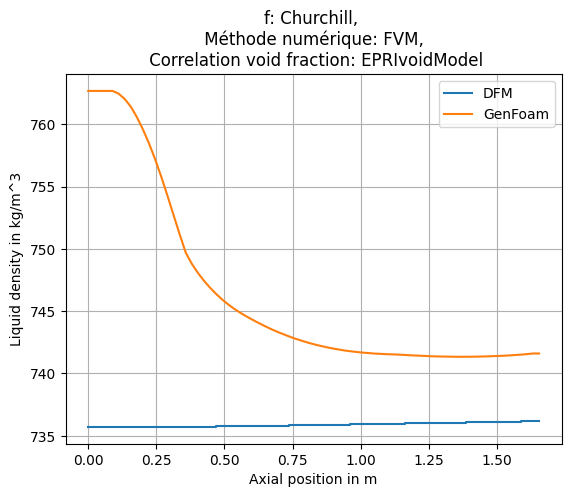

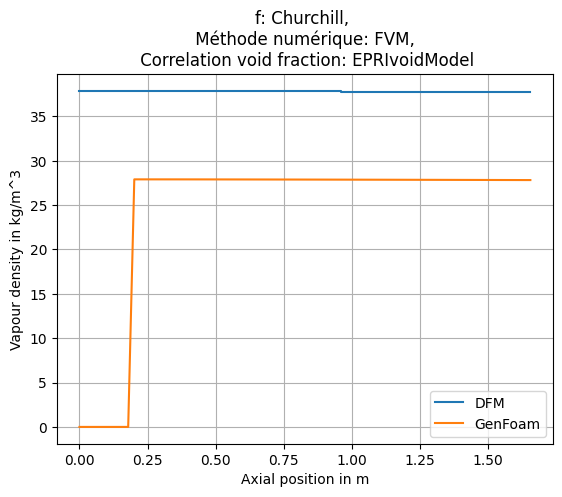

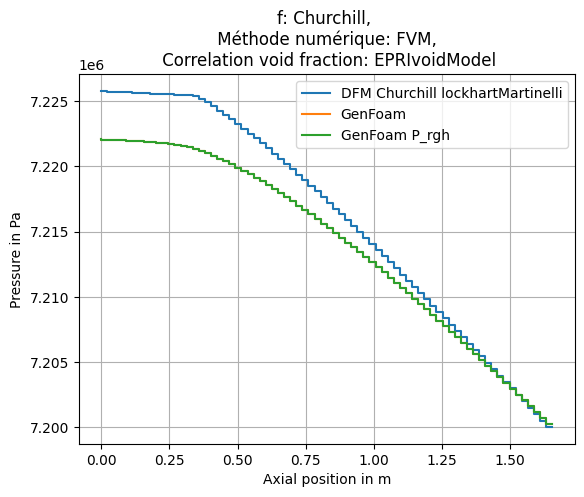

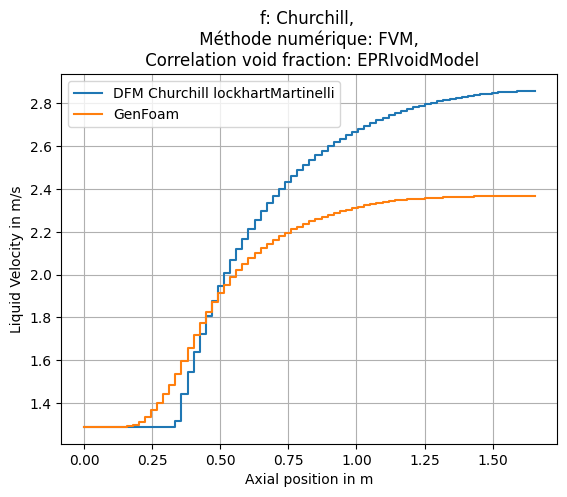

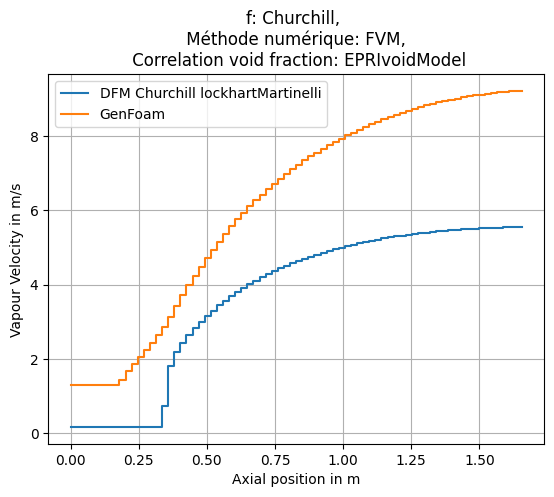

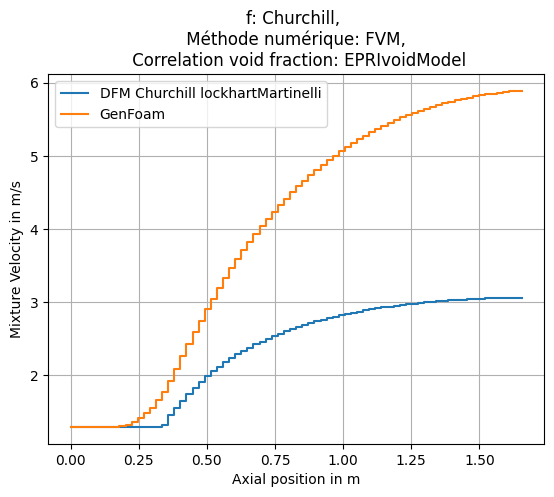

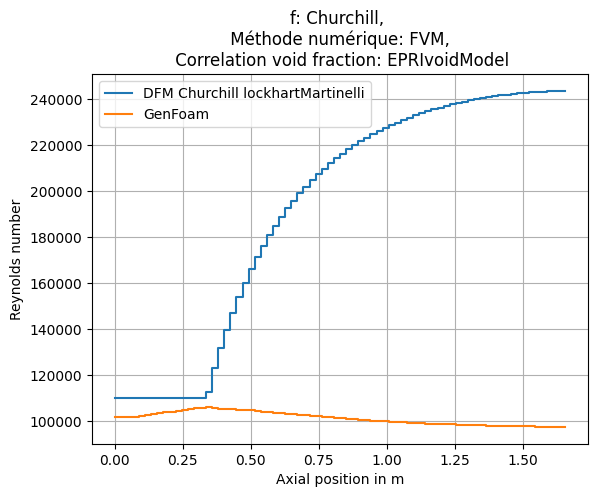

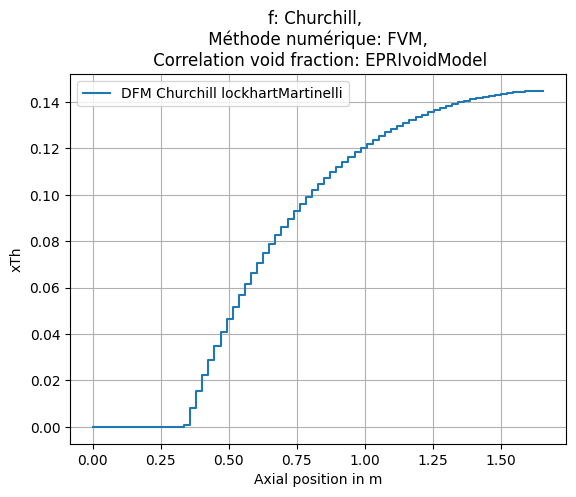

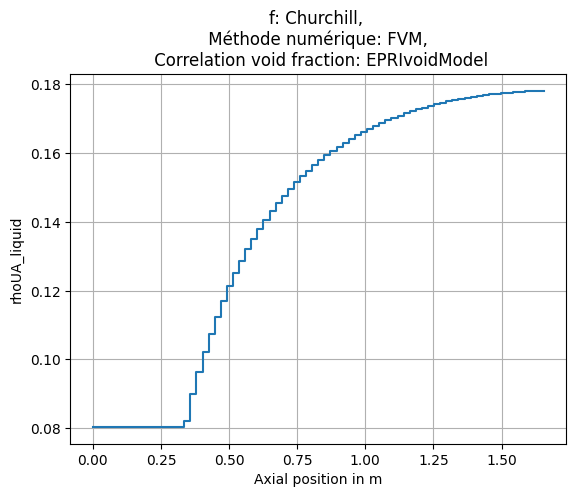

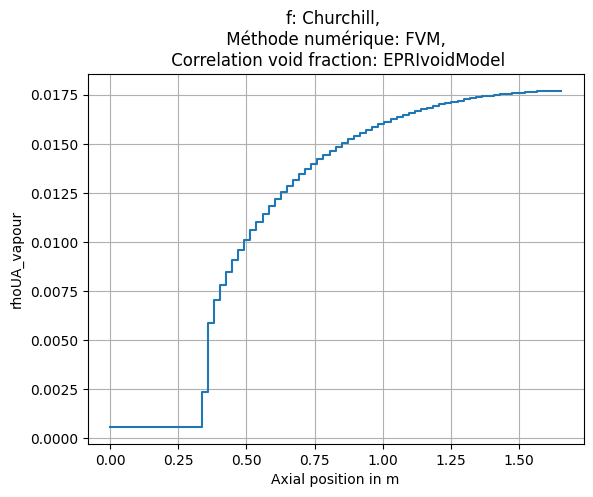

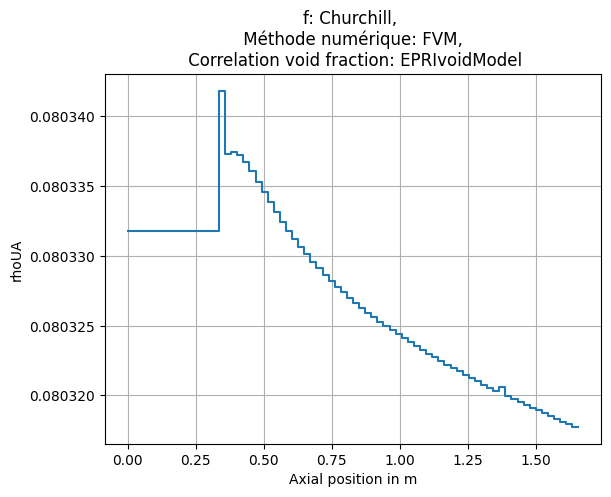

In [4]:
plotter = GFPlotter(caseMerge, rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\AT10_MPHYS\25kW', "MPHYS_at10_25kW")
plotter.plotComparison()